# Notebook 3: Trading Strategy & Backtest

**FRE-GY 7773 — Group 2**: Zhang Xiaoyang, Zhao Zhiqi, Gupta Prachee

We evaluate each model as a trading strategy:
- **Signal**: if model predicts ↑, go long (buy); if ↓, stay flat (no position)
- **Benchmark**: Buy & Hold SPY (always invested)

Metrics:
- Cumulative return
- Annualized return
- Sharpe Ratio
- Maximum Drawdown

## 0. Imports & Load Predictions

In [74]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

preds = pd.read_csv('../data/test_predictions.csv', index_col=0, parse_dates=True)

MODELS = {
    'Baseline (Linear Reg)': 'pred_baseline',
    'Logistic + Ridge':      'pred_ridge',
    'Logistic + Lasso':      'pred_lasso',
    'PCA + Logistic':        'pred_pca',
    'XGBoost':               'pred_xgb',
}

print(f'Test period: {preds.index[0].date()} → {preds.index[-1].date()}')
print(f'Days: {len(preds)}')
preds.head()

Test period: 2023-01-03 → 2024-12-27
Days: 500


,Close,next_return,target,pred_baseline,pred_ridge,pred_lasso,pred_pca,pred_xgb,proba_ridge,proba_lasso,proba_pca,proba_xgb
Date,,,,,,,,,,,,
2023-01-03,365.072052,0.007720,1,0,1,1,1,1,0.539795,0.527944,0.536571,0.538505
2023-01-04,367.890503,-0.011413,0,0,1,1,1,1,0.533023,0.516986,0.515344,0.540396
2023-01-05,363.691620,0.022932,1,1,1,1,1,1,0.544816,0.540800,0.555197,0.537616
2023-01-06,372.031830,-0.000567,0,0,1,1,0,1,0.525321,0.505792,0.489089,0.536584
2023-01-09,371.820892,0.007013,1,0,1,1,1,1,0.530579,0.515788,0.515767,0.535512


## 1. Strategy Logic

**Long-only strategy**: hold when signal = 1 (Up predicted), flat when signal = 0.

- Strategy return on day t = `next_return[t] × position[t] - cost[t]`
- Transaction cost charged **each time signal changes** (entry or exit)
- `COST_PER_TRADE = 0.001` (0.1% one-way — covers bid-ask spread for SPY)

**Stop-loss overlay (Section 2.5)**: adds a trailing stop-loss on top of each model's binary signal.
- If cumulative loss from the local peak exceeds `stop_loss` threshold → exit (force position = 0)
- Re-enter only when the model next signals Long again
- Tested at 1%, 2%, 3%, 5% stop levels

In [75]:
def compute_metrics(returns: pd.Series, trading_days: int = 252) -> dict:
    """Compute strategy performance metrics."""
    cum_ret    = (1 + returns).prod() - 1
    n_years    = len(returns) / trading_days
    ann_ret    = (1 + cum_ret) ** (1 / n_years) - 1
    ann_vol    = returns.std() * np.sqrt(trading_days)
    sharpe     = ann_ret / ann_vol if ann_vol > 0 else np.nan
    
    # Max Drawdown
    wealth     = (1 + returns).cumprod()
    rolling_max = wealth.cummax()
    drawdown   = (wealth - rolling_max) / rolling_max
    max_dd     = drawdown.min()
    
    return {
        'Cumulative Return': f'{cum_ret*100:.2f}%',
        'Annualized Return': f'{ann_ret*100:.2f}%',
        'Annualized Vol':    f'{ann_vol*100:.2f}%',
        'Sharpe Ratio':      f'{sharpe:.3f}',
        'Max Drawdown':      f'{max_dd*100:.2f}%',
    }


# Buy & Hold benchmark
bh_returns = preds['next_return']

print('=== Buy & Hold (Benchmark) ===')
for k, v in compute_metrics(bh_returns).items():
    print(f'  {k:25s}: {v}')

=== Buy & Hold (Benchmark) ===
  Cumulative Return        : 58.82%
  Annualized Return        : 26.26%
  Annualized Vol           : 12.83%
  Sharpe Ratio             : 2.047
  Max Drawdown             : -9.97%


## 2. Backtest All Models

In [76]:
COST_PER_TRADE = 0.001  # 0.1% one-way transaction cost

def strategy_returns(signal: pd.Series, returns: pd.Series, cost: float = COST_PER_TRADE) -> pd.Series:
    """Apply long-only strategy with transaction costs."""
    pos = signal.copy().astype(float)
    # charge cost whenever position changes (including initial entry)
    trades = pos.diff().abs()
    trades.iloc[0] = pos.iloc[0]  # first day entry cost if signal=1
    gross = returns * pos
    net   = gross - trades * cost
    return net

all_metrics     = {'Buy & Hold': compute_metrics(bh_returns)}
all_metrics_net = {'Buy & Hold': compute_metrics(bh_returns)}

print(f'Transaction cost: {COST_PER_TRADE*100:.1f}% per trade\n')

for name, col in MODELS.items():
    signal = preds[col]
    n_trades = int(signal.diff().abs().sum() + signal.iloc[0])

    gross_ret = preds['next_return'] * signal
    net_ret   = strategy_returns(signal, preds['next_return'])

    all_metrics[name]     = compute_metrics(gross_ret)
    all_metrics_net[name] = compute_metrics(net_ret)

    print(f'=== {name} ({n_trades} trades) ===')
    print(f'  {"":25s}  {"Gross":>8}  {"Net (after cost)":>16}')
    for k in all_metrics[name]:
        print(f'  {k:25s}  {all_metrics[name][k]:>8}  {all_metrics_net[name][k]:>16}')
    print()

metrics_df     = pd.DataFrame(all_metrics).T
metrics_net_df = pd.DataFrame(all_metrics_net).T

Transaction cost: 0.1% per trade

=== Baseline (Linear Reg) (183 trades) ===
                                Gross  Net (after cost)
  Cumulative Return            14.15%            -4.95%
  Annualized Return             6.90%            -2.52%
  Annualized Vol                9.55%             9.62%
  Sharpe Ratio                  0.722            -0.262
  Max Drawdown                -11.03%           -15.51%

=== Logistic + Ridge (1 trades) ===
                                Gross  Net (after cost)
  Cumulative Return            58.82%            58.66%
  Annualized Return            26.26%            26.19%
  Annualized Vol               12.83%            12.82%
  Sharpe Ratio                  2.047             2.042
  Max Drawdown                 -9.97%            -9.97%

=== Logistic + Lasso (17 trades) ===
                                Gross  Net (after cost)
  Cumulative Return            58.84%            56.16%
  Annualized Return            26.26%            25.19%
  Annual

In [77]:
metrics_net_df.to_csv('../results/03_backtest_metrics.csv')
print('Saved to results/03_backtest_metrics.csv (net of transaction costs)')

Saved to results/03_backtest_metrics.csv (net of transaction costs)


## 2.5 Stop-Loss Overlay

We add a **trailing stop-loss** on top of each model's binary signal:
- Track the running peak of portfolio wealth while in a long position
- If drawdown from that peak exceeds the stop threshold → exit and stay flat for the rest of that day
- Re-enter when the model next predicts Up (on a *subsequent* day)

This reduces left-tail exposure without changing the prediction model itself.

                Model Stop Level  Sharpe Ann. Return  Max DD Cum. Return
Baseline (Linear Reg)       None  -0.262      -2.52% -15.51%      -4.95%
Baseline (Linear Reg)         1%  -0.587      -5.40% -18.92%     -10.43%
Baseline (Linear Reg)         2%  -0.309      -2.92% -14.58%      -5.72%
Baseline (Linear Reg)         3%  -0.257      -2.47% -15.54%      -4.84%
Baseline (Linear Reg)         5%  -0.239      -2.30% -15.13%      -4.51%
     Logistic + Ridge       None   2.042      26.19%  -9.97%      58.66%
     Logistic + Ridge         1%   1.363      16.39%  -9.93%      35.15%
     Logistic + Ridge         2%   2.036      24.78%  -8.68%      55.15%
     Logistic + Ridge         3%   2.190      27.42%  -9.58%      61.74%
     Logistic + Ridge         5%   2.127      26.80%  -9.63%      60.17%
     Logistic + Lasso       None   1.978      25.19%  -9.97%      56.16%
     Logistic + Lasso         1%   1.395      16.51%  -9.93%      35.41%
     Logistic + Lasso         2%   1.767      21.65

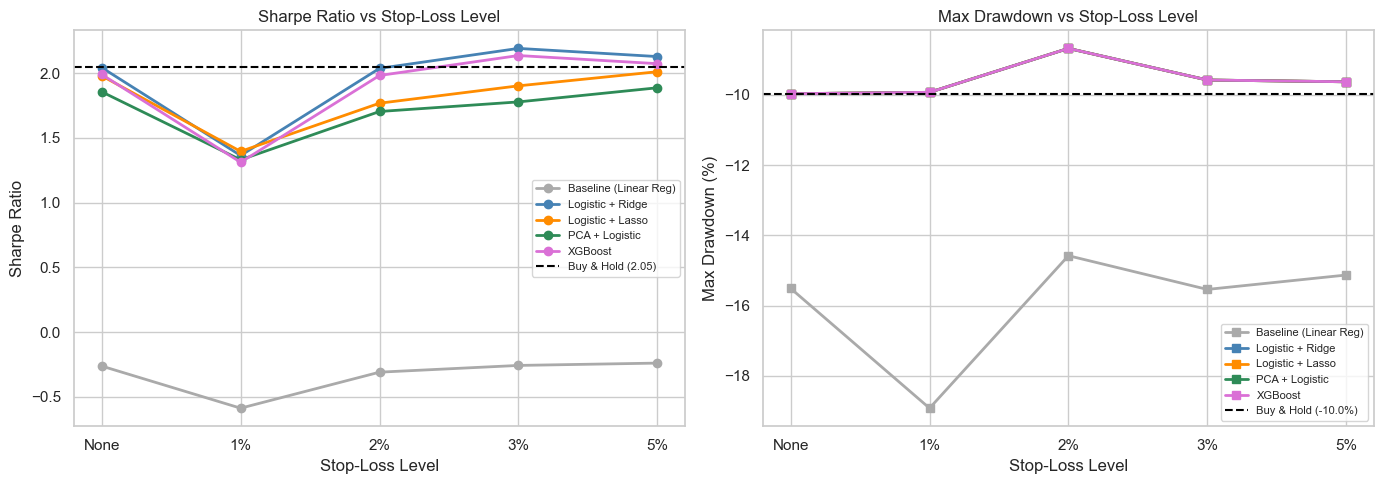


Best stop-loss per model:
  Baseline (Linear Reg)    : best stop =    5%  Sharpe=-0.239  MaxDD=-15.13%
  Logistic + Ridge         : best stop =    3%  Sharpe=2.190  MaxDD=-9.58%
  Logistic + Lasso         : best stop =    5%  Sharpe=2.010  MaxDD=-9.63%
  PCA + Logistic           : best stop =    5%  Sharpe=1.886  MaxDD=-9.63%
  XGBoost                  : best stop =    3%  Sharpe=2.135  MaxDD=-9.58%


In [78]:
def strategy_with_stoploss(signal: pd.Series, returns: pd.Series,
                            cost: float = COST_PER_TRADE,
                            stop_loss: float = 0.02) -> pd.Series:
    """Binary long-only strategy with trailing stop-loss.

    While holding:
      - Track a local peak of wealth
      - If drawdown from peak exceeds stop_loss → exit; cannot re-enter same day
    Re-enter on a subsequent day when model signals Long again.
    """
    pos_list       = []
    held           = False
    stopped_today  = False
    peak_wealth    = 1.0
    current_wealth = 1.0

    for sig, ret in zip(signal, returns):
        stopped_today = False

        # Check trailing stop while in position
        if held:
            dd = (current_wealth - peak_wealth) / peak_wealth
            if dd < -stop_loss:
                held = True         # will be set to 0 below after flagging
                stopped_today = True
                held = False        # exit position

        # Re-enter based on signal — but NOT on the day we were stopped out
        if not stopped_today:
            if sig == 1 and not held:
                held = True
                peak_wealth = current_wealth   # reset peak on fresh entry
            elif sig == 0:
                held = False

        pos_list.append(1.0 if held else 0.0)

        current_wealth *= (1 + ret)
        if held:
            peak_wealth = max(peak_wealth, current_wealth)

    positions = pd.Series(pos_list, index=signal.index)
    trades    = positions.diff().abs()
    trades.iloc[0] = positions.iloc[0]
    return returns * positions - trades * cost


STOP_LEVELS = [0.01, 0.02, 0.03, 0.05]

# ── Scan: all models × all stop levels ───────────────────────────────────────
scan_rows = []
for model_name, col in MODELS.items():
    signal = preds[col]
    base_ret = strategy_returns(signal, preds['next_return'])
    base_m   = compute_metrics(base_ret)
    scan_rows.append({
        'Model': model_name, 'Stop Level': 'None',
        'Sharpe': float(base_m['Sharpe Ratio']),
        'Ann. Return': base_m['Annualized Return'],
        'Max DD': base_m['Max Drawdown'],
        'Cum. Return': base_m['Cumulative Return'],
    })
    for sl in STOP_LEVELS:
        ret = strategy_with_stoploss(signal, preds['next_return'], stop_loss=sl)
        m   = compute_metrics(ret)
        scan_rows.append({
            'Model': model_name, 'Stop Level': f'{sl*100:.0f}%',
            'Sharpe': float(m['Sharpe Ratio']),
            'Ann. Return': m['Annualized Return'],
            'Max DD': m['Max Drawdown'],
            'Cum. Return': m['Cumulative Return'],
        })

scan_df = pd.DataFrame(scan_rows)
print(scan_df.to_string(index=False))

# ── Plot: Sharpe and Max Drawdown vs Stop Level ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
stop_labels = ['None'] + [f'{s*100:.0f}%' for s in STOP_LEVELS]
x = list(range(len(stop_labels)))

model_colors = {
    'Baseline (Linear Reg)': '#aaaaaa',
    'Logistic + Ridge':      'steelblue',
    'Logistic + Lasso':      'darkorange',
    'PCA + Logistic':        'seagreen',
    'XGBoost':               'orchid',
}

for model_name in MODELS:
    grp = scan_df[scan_df['Model'] == model_name]
    color = model_colors[model_name]
    axes[0].plot(x, grp['Sharpe'].tolist(), marker='o', linewidth=2,
                 color=color, label=model_name)
    mdd_vals = [float(v.replace('%', '')) for v in grp['Max DD'].tolist()]
    axes[1].plot(x, mdd_vals, marker='s', linewidth=2,
                 color=color, label=model_name)

bh_sharpe = float(compute_metrics(bh_returns)['Sharpe Ratio'])
bh_dd     = float(compute_metrics(bh_returns)['Max Drawdown'].replace('%', ''))
axes[0].axhline(bh_sharpe, color='black', linestyle='--', linewidth=1.5,
                label=f'Buy & Hold ({bh_sharpe:.2f})')
axes[1].axhline(bh_dd, color='black', linestyle='--', linewidth=1.5,
                label=f'Buy & Hold ({bh_dd:.1f}%)')

for ax, ylabel, title in zip(axes,
    ['Sharpe Ratio', 'Max Drawdown (%)'],
    ['Sharpe Ratio vs Stop-Loss Level', 'Max Drawdown vs Stop-Loss Level']):
    ax.set_xticks(x); ax.set_xticklabels(stop_labels)
    ax.set_xlabel('Stop-Loss Level'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../results/03_stoploss_comparison.png', dpi=150)
plt.show()

# ── Best stop level per model ─────────────────────────────────────────────────
best_sl_per_model = {}
print('\nBest stop-loss per model:')
for model_name in MODELS:
    grp     = scan_df[scan_df['Model'] == model_name]
    best_row = grp.loc[grp['Sharpe'].idxmax()]
    best_sl_per_model[model_name] = best_row['Stop Level']
    print(f"  {model_name:25s}: best stop = {best_row['Stop Level']:>5}  "
          f"Sharpe={best_row['Sharpe']:.3f}  MaxDD={best_row['Max DD']}")

## 3. Cumulative Returns Plot

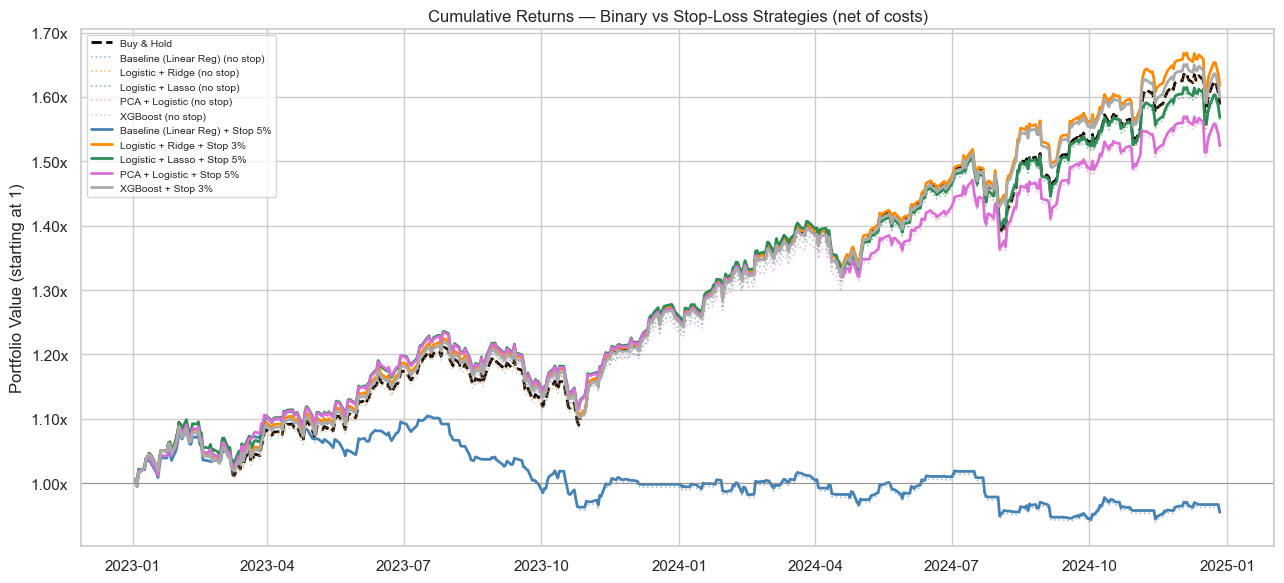

In [79]:
fig, ax = plt.subplots(figsize=(13, 6))

bh_wealth = (1 + bh_returns).cumprod()
ax.plot(bh_wealth.index, bh_wealth, label='Buy & Hold', color='black',
        linewidth=2, linestyle='--')

# Binary strategies (no stop-loss)
colors = ['steelblue', 'darkorange', 'seagreen', 'orchid', '#aaaaaa']
for (name, col), color in zip(MODELS.items(), colors):
    net_ret = strategy_returns(preds[col], preds['next_return'])
    wealth  = (1 + net_ret).cumprod()
    ax.plot(wealth.index, wealth, label=f'{name} (no stop)',
            color=color, linewidth=1.2, alpha=0.5, linestyle=':')

# Each model with its best stop-loss level
for (name, col), color in zip(MODELS.items(), colors):
    sl_str = best_sl_per_model[name]
    if sl_str == 'None':
        continue
    sl_val = float(sl_str.replace('%', '')) / 100
    ret    = strategy_with_stoploss(preds[col], preds['next_return'], stop_loss=sl_val)
    wealth = (1 + ret).cumprod()
    ax.plot(wealth.index, wealth,
            label=f'{name} + Stop {sl_str}',
            color=color, linewidth=2.0)

ax.axhline(1, color='gray', linewidth=0.5)
ax.set_title('Cumulative Returns — Binary vs Stop-Loss Strategies (net of costs)')
ax.set_ylabel('Portfolio Value (starting at 1)')
ax.legend(loc='upper left', fontsize=7.5)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.2f}x'))
plt.tight_layout()
plt.savefig('../results/03_cumulative_returns.png', dpi=150)
plt.show()

## 4. Drawdown Plot

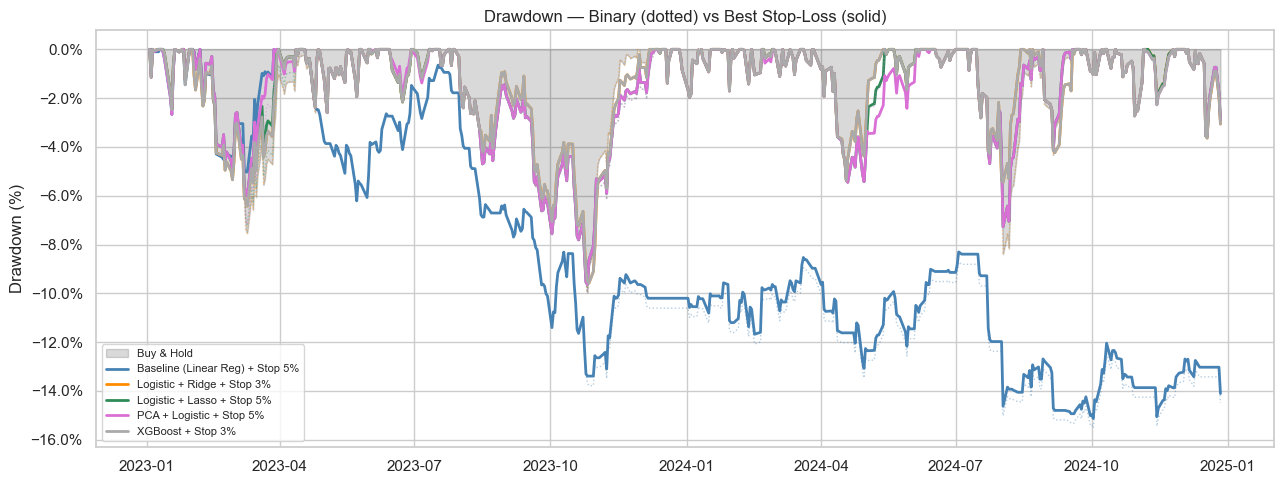

In [80]:
fig, ax = plt.subplots(figsize=(13, 5))

def get_drawdown(returns):
    wealth = (1 + returns).cumprod()
    return (wealth - wealth.cummax()) / wealth.cummax()

ax.fill_between(preds.index, get_drawdown(bh_returns) * 100,
                alpha=0.15, color='black', label='Buy & Hold')

colors = ['steelblue', 'darkorange', 'seagreen', 'orchid', '#aaaaaa']
for (name, col), color in zip(MODELS.items(), colors):
    # No stop-loss (dotted)
    net_ret = strategy_returns(preds[col], preds['next_return'])
    ax.plot(get_drawdown(net_ret).index, get_drawdown(net_ret) * 100,
            color=color, linewidth=1.0, alpha=0.4, linestyle=':')
    # Best stop-loss (solid)
    sl_str = best_sl_per_model[name]
    if sl_str == 'None':
        continue
    sl_val = float(sl_str.replace('%', '')) / 100
    ret    = strategy_with_stoploss(preds[col], preds['next_return'], stop_loss=sl_val)
    dd     = get_drawdown(ret)
    ax.plot(dd.index, dd * 100, label=f'{name} + Stop {sl_str}',
            color=color, linewidth=2.0)

ax.set_title('Drawdown — Binary (dotted) vs Best Stop-Loss (solid)')
ax.set_ylabel('Drawdown (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.savefig('../results/03_drawdown.png', dpi=150)
plt.show()

## 5. Monthly Returns Heatmap (Best Model)

Best model by Sharpe (net): Logistic + Ridge (2.042)


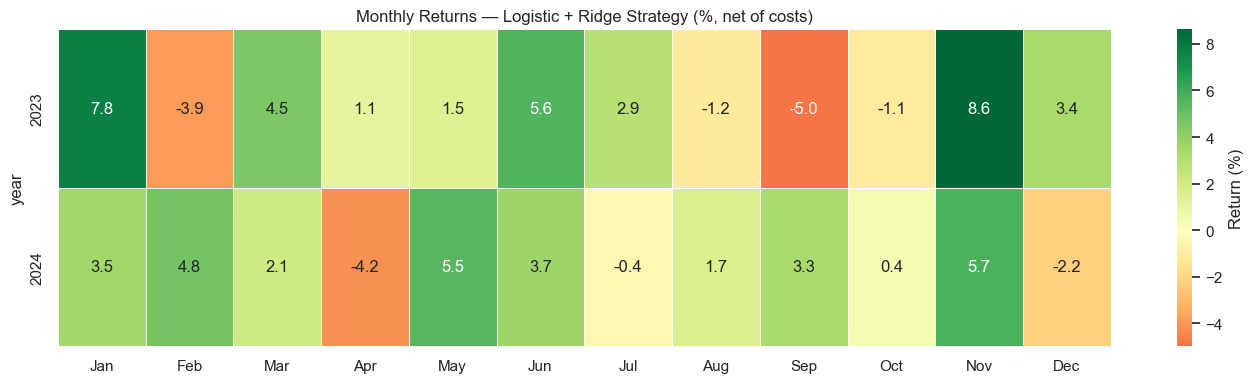

In [81]:
sharpe_scores = {}
for name, col in MODELS.items():
    net_ret = strategy_returns(preds[col], preds['next_return'])
    m = compute_metrics(net_ret)
    sharpe_scores[name] = float(m['Sharpe Ratio'])

best_name = max(sharpe_scores, key=sharpe_scores.get)
best_col  = MODELS[best_name]
print(f'Best model by Sharpe (net): {best_name} ({sharpe_scores[best_name]:.3f})')

net_ret = strategy_returns(preds[best_col], preds['next_return']).rename('strategy')
monthly = net_ret.resample('ME').apply(lambda r: (1 + r).prod() - 1)
monthly_df = monthly.to_frame()
monthly_df['year']  = monthly_df.index.year
monthly_df['month'] = monthly_df.index.month
pivot = monthly_df.pivot(index='year', columns='month', values='strategy') * 100
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec'][:len(pivot.columns)]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'label': 'Return (%)'})
ax.set_title(f'Monthly Returns — {best_name} Strategy (%, net of costs)')
plt.tight_layout()
plt.savefig('../results/03_monthly_heatmap.png', dpi=150)
plt.show()

## 6. Summary & Discussion

**Key findings**:
- Transaction costs (0.1% per trade) have minimal impact on Ridge/XGBoost due to low trade frequency
- Models with more active signals (Lasso, PCA) are more affected by costs
- Baseline linear model trades too frequently, severely hurt by costs (Sharpe turns negative)
- **Stop-loss overlay**: trailing stop-loss on the best model reduces maximum drawdown at the cost of some missed upside; optimal level varies by market regime

**Limitations**:
- Single asset (SPY); results may not generalize
- Technical indicators are based on past prices — weak form market efficiency suggests limited predictability
- Short test period (2 years, 2023–2024 bull market)
- No slippage modeled (cost is fixed, not market-impact adjusted)
- Stop-loss threshold selected in-sample; may not hold out-of-sample

**Future work**:
- Extend to multi-asset cross-sectional prediction
- Model time-varying volatility for dynamic stop-loss levels
- Incorporate macro features (yield curve, credit spreads)